# Ковалев Глеб 367291 Лабораторная 1
# Функции (3 балла)

##0 Imports

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import math
import os
import re
import random
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision
from torchvision.transforms import transforms

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import nltk
from nltk import word_tokenize, sent_tokenize
from scipy import stats


##1.1

Постройте график функции и её производной первого порядка. Также найдите точки экстремума функции, отметьте их на графике другим цветом. Вычисления проведите вручную и приложите скрин расчетов.

$f(x) = (x^2-2x)ln(x)-1.5x^2+4x$


$$f(x)=(x^2-2x)\ln x-\frac{3}{2}x^2+4x$$

Найдём производную функции:

$$
f'(x)=\left((x^2-2x)\ln x-\frac{3}{2}x^2+4x\right)'
$$

Используем правило: производная суммы (или разности) равна сумме (или разности) производных:

$$
(u+v-w)'=u'+v'-w'
$$

Тогда

$$
f'(x)=\bigl((x^2-2x)\ln x\bigr)'-\left(\frac{3}{2}x^2\right)'+(4x)'
$$

Теперь найдём производную каждого слагаемого отдельно.

**1. Производная выражения $\boldsymbol{(x^2-2x)\ln x}$**

Здесь произведение двух функций:

$$
u=x^2-2x,\qquad v=\ln x
$$

Применяем **правило произведения**:

$$
(uv)'=u'v+uv'
$$

Значит,

$$
\bigl((x^2-2x)\ln x\bigr)'=(x^2-2x)'\ln x+(x^2-2x)(\ln x)'
$$

Теперь найдём производную функции $x^2-2x$.

Снова используем правило производной суммы:

$$
(x^2-2x)'=(x^2)'-(2x)'
$$

По **степенному правилу**

$$
(x^n)'=nx^{n-1}
$$

получаем:

$$
(x^2)'=2x
$$

Для $(2x)'$ используем правило: постоянный множитель можно выносить за знак производной:

$$
(C\cdot u)'=C\cdot u'
$$

Тогда

$$
(2x)'=2\cdot (x)'=2\cdot 1=2
$$

Следовательно,

$$
(x^2-2x)'=2x-2
$$

Теперь найдём производную $\ln x$. По табличной формуле:

$$
(\ln x)'=\frac{1}{x}
$$

Подставляем всё в правило произведения:

$$
\bigl((x^2-2x)\ln x\bigr)'=(2x-2)\ln x+(x^2-2x)\cdot \frac{1}{x}
$$

Упростим второе слагаемое:

$$
(x^2-2x)\cdot \frac{1}{x}=\frac{x^2-2x}{x}=x-2
$$

Значит,

$$
\bigl((x^2-2x)\ln x\bigr)'=(2x-2)\ln x+x-2
$$

**2. Производная выражения $\boldsymbol{-\frac{3}{2}x^2}$**

Используем правило постоянного множителя:

$$
\left(\frac{3}{2}x^2\right)'=\frac{3}{2}(x^2)'
$$

По степенному правилу:

$$
(x^2)'=2x
$$

Поэтому

$$
\left(\frac{3}{2}x^2\right)'=\frac{3}{2}\cdot 2x=3x
$$

Так как в функции стоит минус перед этим выражением, получаем:

$$
\left(-\frac{3}{2}x^2\right)'=-3x
$$

**3. Производная выражения $\boldsymbol{4x}$**

Снова применяем правило постоянного множителя:

$$
(4x)'=4\cdot (x)'
$$

Так как

$$
(x)'=1,
$$

то

$$
(4x)'=4\cdot 1=4
$$

**4. Соберём всё вместе**

Подставляем найденные производные:

$$
f'(x)=\bigl((2x-2)\ln x+x-2\bigr)-3x+4
$$

Раскроем скобки:

$$
f'(x)=(2x-2)\ln x+x-2-3x+4
$$

Приведём подобные слагаемые:

$$
x-3x=-2x,\qquad -2+4=2
$$

Итак,

$$
f'(x)=(2x-2)\ln x-2x+2
$$

Ответ:

$$
\boxed{f'(x)=(2x-2)\ln x-2x+2}
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return (x**2 - 2*x) * np.log(x) - 1.5*x**2 + 4*x

def f_dx(x):
    return (2*x - 2) * np.log(x) - 2*x + 2

x_values = np.linspace(0.1, 5, 1000)

##1.2

Найдите частные производные функции $f(x, y, z) = 15x^2 + exp(x^2 + y^3)*cos(z)$ с помощью [SymPy](https://www.geeksforgeeks.org/python-sympy-diff-method/)

In [ ]:
x, y, z = sp.symbols('x y z')
f = 15*x**2 + sp.exp(x**2 + y**3) * sp.cos(z)

df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)
df_dz = sp.diff(f, z)

print("f(x, y, z) =")
sp.pprint(f)

print("\nЧастная производная по x:")
sp.pprint(df_dx)

print("\nЧастная производная по y:")
sp.pprint(df_dy)

print("\nЧастная производная по z:")
sp.pprint(df_dz)

f(x, y, z) =
          2    3       
    2    x  + y        
15⋅x  + ℯ       ⋅cos(z)

Частная производная по x:
      2    3              
     x  + y               
2⋅x⋅ℯ       ⋅cos(z) + 30⋅x

Частная производная по y:
       2    3       
   2  x  + y        
3⋅y ⋅ℯ       ⋅cos(z)

Частная производная по z:
   2    3       
  x  + y        
-ℯ       ⋅sin(z)


##2

Не всегда значения функций возможно рассчитать напрямую, однако их можно вычислить приближенно, используя, например, ряды Тейлора. Реализуйте расчет $e^x$. Сравните значения, получаемые с различной точностью приближения (5, 10, 15), с numpy-реализацией. Постройте график, отобразив на нём все четыре линии.

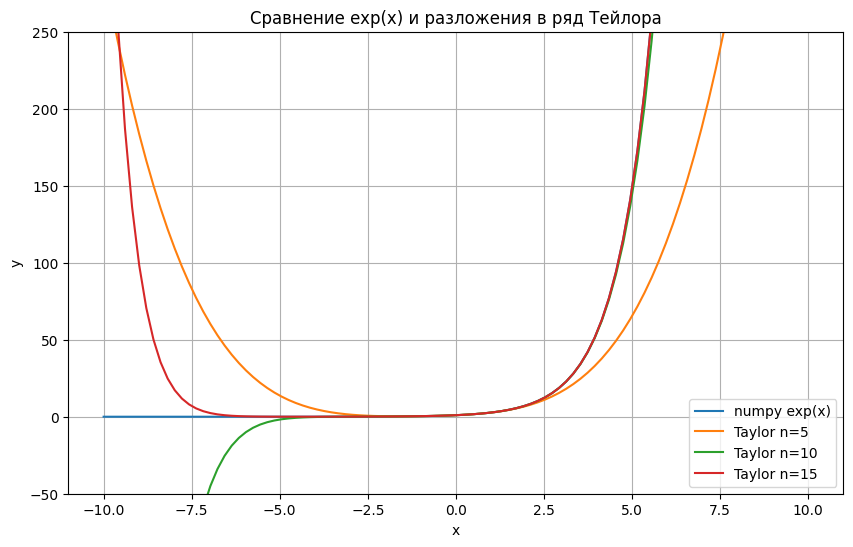

In [ ]:
def taylor_exp(x, n):
    result = np.zeros_like(x, dtype=float)
    for k in range(n):
        result += x**k / math.factorial(k)
    return result

x_values = np.linspace(-10, 10, 100)

y_np = np.exp(x_values)
y_5 = taylor_exp(x_values, 5)
y_10 = taylor_exp(x_values, 10)
y_15 = taylor_exp(x_values, 15)

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_np, label='numpy exp(x)')
plt.plot(x_values, y_5, label='Taylor n=5')
plt.plot(x_values, y_10, label='Taylor n=10')
plt.plot(x_values, y_15, label='Taylor n=15')

plt.ylim(-50, 250)
plt.grid(True)
plt.legend()
plt.title("Сравнение exp(x) и разложения в ряд Тейлора")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

##3

Рассмотрите две следующие функции, часто использующиеся как функции потерь (то есть они помогают оценить качество предсказаний модели).

$MAE (Mean\ Absolute\ Error) = \frac{1}{n} \sum_{i=1}^{n} |y_i - \widehat{y}_i|$

$MSE (Mean\ Squared\ Error) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \widehat{y}_i)^2$

Письменно ответьте на вопросы:

1. Какая проблема присуща MAE с точки зрения дифференцирования?

2. Если в качестве $\widehat{y}_i$ всегда будет предсказываться константное значение, каким оно должно быть, чтобы минимизировать значение каждой из функций?


**1. Какая проблема присуща MAE с точки зрения дифференцирования?**

Функция MAE имеет вид

$$
MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \widehat y_i|.
$$

Проблема MAE состоит в том, что модуль $|x|$ не дифференцируем в точке $x=0$.
Значит, функция ошибки MAE не является дифференцируемой в точках, где

$$
y_i - \widehat y_i = 0.
$$

Из-за этого при использовании градиентных методов оптимизации возникают сложности: в некоторых точках градиент не определён.

---

**2. Если $\widehat y_i$ всегда будет предсказываться как константное значение, каким оно должно быть, чтобы минимизировать значение каждой из функций?**

Пусть модель всегда предсказывает одно и то же число $c$:

$$
\widehat y_i = c.
$$

Тогда:

- для MAE минимизируется выражение

$$
\frac{1}{n}\sum_{i=1}^{n} |y_i - c|,
$$

и его минимум достигается, когда $c$ равно **медиане** значений $y_i$;

- для MSE минимизируется выражение

$$
\frac{1}{n}\sum_{i=1}^{n} (y_i - c)^2,
$$

и его минимум достигается, когда $c$ равно **среднему арифметическому** значений $y_i$:

$$
c = \frac{1}{n}\sum_{i=1}^{n} y_i.
$$

**Ответ:**  
для MAE оптимальной константой является **медиана**,  
для MSE оптимальной константой является **среднее арифметическое**.

# Матрицы. Векторы (2 балла)

##1

Реализуйте следующие паттерны. Не используйте циклы! Все матрицы квадратные со стороной длины n. Примеры приведены для n=5.

1. Шахматная доска
```
[[0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0.]]
 ```
2. Полоса шириной 3 относительно главной диагонали
```
[[1. 1. 0. 0. 0.]
 [1. 1. 1. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]]
 ```
3. Кайма из единиц
```
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
 ```
4. Полосы
```
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]]
 ```
5. Верхний треугольник
```
[[1. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1.]]
 ```


In [ ]:
n = 5

chess = (np.indices((n, n)).sum(axis=0) % 2).astype(float)

print("1. Шахматная доска")
print(chess)

band = (np.abs(np.subtract.outer(np.arange(n), np.arange(n))) <= 1).astype(float)

print("\n2. Полоса шириной 3 относительно главной диагонали")
print(band)

border = np.ones((n, n), dtype=float)
border[1:-1, 1:-1] = 0

print("\n3. Кайма из единиц")
print(border)

stripes = (np.arange(n)[:, None] % 2).repeat(n, axis=1).astype(float)

print("\n4. Полосы")
print(stripes)

upper = np.triu(np.ones((n, n), dtype=float))

print("\n5. Верхний треугольник")
print(upper)

1. Шахматная доска
[[0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0.]]

2. Полоса шириной 3 относительно главной диагонали
[[1. 1. 0. 0. 0.]
 [1. 1. 1. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]]

3. Кайма из единиц
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

4. Полосы
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]]

5. Верхний треугольник
[[1. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1.]]


##2

Пусть дан вектор следующего вида. Преобразуйте его, чтобы получить две матрицы: первая должна содержать одинаковые значения column-wise (столбец целиком из нулей, столбец целиком из единиц и так далее), а вторая - row-wise. Не используйте циклы.

In [ ]:
n = 5
vector = np.hstack([[i for i in range(n)] for _ in range(n)])
print("vector =")
print(vector)

base = vector.reshape(n, n)

column_wise = base.T

row_wise = base

print("\nМатрица column-wise:")
print(column_wise)

print("\nМатрица row-wise:")
print(row_wise)

vector =
[0 1 2 3 4 0 1 2 3 4 0 1 2 3 4 0 1 2 3 4 0 1 2 3 4]

Матрица column-wise:
[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]

Матрица row-wise:
[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]


# Введение в PyTorch (2 балла)

С точки зрения синтаксиса PyTorch похож на NumPy, основная разница заключается в том, что данный фреймворк предназначен для автоматического расчета градиентов. [Вот тут](https://github.com/torch/torch7/wiki/Torch-for-Numpy-users) можно почитать про то, как соотносятся две эти библиотеки.

[Неплохой курс чисто про PyTorch](https://www.learnpytorch.io/)

[Документация PyTorch](https://pytorch.org/)

In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

##1

1. Создайте два вещественных тензора: $a$ размером (10, 2) и $b$ размером (, 20)

2. Создайте тензор c, являющийся тензором $b$, но размера (2, 2, 5)

3. Выведите первый столбец матрицы $a$ с помощью индексации

4. Создайте тензор $d$, являющийся тензором $b$, но размера (10, 2). Произведите все арифметические операции с тензорами $a$ и $d$

In [ ]:
a = torch.randn(10, 2, dtype=torch.float32)
b = torch.randn(20, dtype=torch.float32)

print("Tensor a:")
print(a)
print("Shape of a:", a.shape)

print("\nTensor b:")
print(b)
print("Shape of b:", b.shape)

c = b.reshape(2, 2, 5)

print("\nTensor c = reshape(b) -> (2, 2, 5):")
print(c)
print("Shape of c:", c.shape)

print("\nFirst column of a:")
print(a[:, 0])

d = b.reshape(10, 2)

print("\nTensor d = reshape(b) -> (10, 2):")
print(d)
print("Shape of d:", d.shape)

print("\na + d:")
print(a + d)

print("\na - d:")
print(a - d)

print("\na * d:")
print(a * d)

print("\na / d:")
print(a / d)

Tensor a:
tensor([[-0.9713, -0.5873],
        [-2.3245, -0.8784],
        [ 0.0591, -1.1712],
        [ 0.6089, -1.4814],
        [ 1.9437,  0.9387],
        [ 0.2648, -0.8008],
        [ 2.6668, -0.6656],
        [-1.2645,  0.1253],
        [-0.7958,  1.5887],
        [-1.5875, -0.6345]])
Shape of a: torch.Size([10, 2])

Tensor b:
tensor([-0.0381, -0.0890, -0.6173, -0.6526,  1.2391,  0.2612,  0.8609, -1.0079,
         0.2578,  2.0466, -0.6811,  0.9115,  0.0544, -0.0755,  0.7999, -0.3039,
        -0.6900,  1.0410, -1.1499, -0.1272])
Shape of b: torch.Size([20])

Tensor c = reshape(b) -> (2, 2, 5):
tensor([[[-0.0381, -0.0890, -0.6173, -0.6526,  1.2391],
         [ 0.2612,  0.8609, -1.0079,  0.2578,  2.0466]],

        [[-0.6811,  0.9115,  0.0544, -0.0755,  0.7999],
         [-0.3039, -0.6900,  1.0410, -1.1499, -0.1272]]])
Shape of c: torch.Size([2, 2, 5])

First column of a:
tensor([-0.9713, -2.3245,  0.0591,  0.6089,  1.9437,  0.2648,  2.6668, -1.2645,
        -0.7958, -1.5875])

Tenso

## 2

1. Создайте тензор *целых чисел* `images` размерности (100, 200, 200, 3) (можно интерпретировать это как 100 картинок размера 200х200 с тремя цветовыми каналами, то есть 100 цветных изображений 200х200). Заполните его нулями  

2. Сделайте так, чтобы у $i$-ой по порядку картинки была нарисована белая полоса толщиной два пикселя в строках, которые соответствуют номеру картинки * 2. Например, у 3-ей по порядку картинки белая полоска будет занимать 6 и 7 строки, у 99 - 198 и 199. Сделать белую строку можно, записав в ячейки тензора число 255 (по всем трём каналам). Выведите несколько примеров с помощью `pyplot`  

3. Посчитайте среднее тензора `images` по 1-ой оси (по сути - средняя картинка), умножьте полученный тензор на 70. Нарисуйте с помощью `pyplot`, должна получиться серая картинка (при взятии среднего нужно привести тензор к float с помощью `.float()`, при отрисовке обратно к int с помощью `.int()`)

Shape of images: torch.Size([100, 200, 200, 3])
Dtype of images: torch.int32


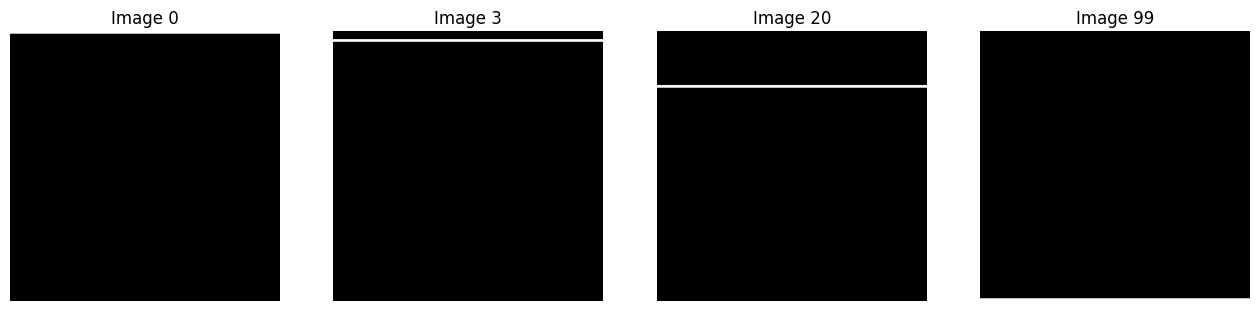

In [ ]:
images = torch.zeros((100, 200, 200, 3), dtype=torch.int32)

print("Shape of images:", images.shape)
print("Dtype of images:", images.dtype)

for i in range(100):
    row1 = 2 * i
    row2 = 2 * i + 1
    if row1 < 200:
        images[i, row1, :, :] = 255
    if row2 < 200:
        images[i, row2, :, :] = 255

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sample_ids = [0, 3, 20, 99]
for ax, idx in zip(axes, sample_ids):
    ax.imshow(images[idx].numpy().astype("uint8"))
    ax.set_title(f"Image {idx}")
    ax.axis("off")

plt.show()

Shape of mean_image: torch.Size([200, 200, 3])
Dtype of mean_image: torch.float32


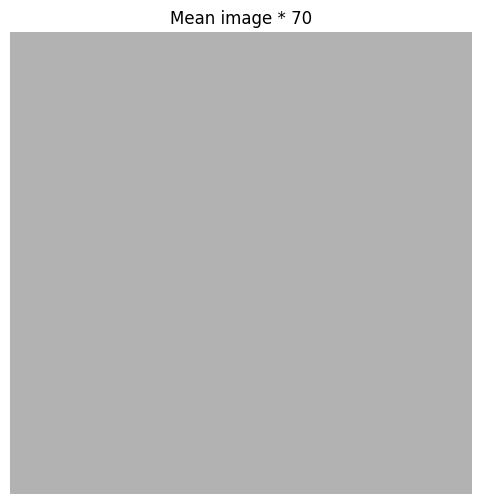

In [ ]:
mean_image = images.float().mean(dim=0) * 70

print("Shape of mean_image:", mean_image.shape)
print("Dtype of mean_image:", mean_image.dtype)

plt.figure(figsize=(6, 6))
plt.imshow(torch.clamp(mean_image, 0, 255).int().numpy().astype("uint8"))
plt.title("Mean image * 70")
plt.axis("off")
plt.show()

## 3

1. Смените среду выполнения на GPU (в Colab нажмите в меню сверху: `Runtime` -> `Change Runtime Type` -> `GPU`, где изначально стоит `None` (`Среда выполнение` - `Сменить среду выполнения`))

2. Объявите тензор $a$ размера (2, 3, 4) и тензор $b$ размера (1, 8, 3) на GPU, иницилизируйте их случайно равномерно (`.uniform_()`)

3. Измените форму тензора $b$, чтобы она совпадала с формой тензора $a$, получите тензор $c$.

4. Переместите тензоры $a$ и $c$ на CPU.

5. Объявите тензор `L = torch.mean((c - a) `**` 2)` и посчитайте градиент $L$ по $c$ ( то есть $\frac{\partial{L}}{\partial{c}})$. Выведите градиент $L$ по $c$. Также вычислите его вручную, чтобы проверить себя.

In [ ]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "GPU not found")

True
Tesla T4


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

a = torch.empty((2, 3, 4), device=device).uniform_(0, 1)
b = torch.empty((1, 8, 3), device=device).uniform_(0, 1)

print("\nTensor a:")
print(a)
print("Shape of a:", a.shape)

print("\nTensor b:")
print(b)
print("Shape of b:", b.shape)

c = b.reshape(2, 3, 4)

print("\nTensor c = reshape(b):")
print(c)
print("Shape of c:", c.shape)

a_cpu = a.cpu()
c_cpu = c.cpu()

print("\na_cpu device:", a_cpu.device)
print("c_cpu device:", c_cpu.device)

c = c.clone().detach().requires_grad_(True)
a_const = a.clone().detach()

L = torch.mean((c - a_const) ** 2)

print("\nL:")
print(L)

L.backward()

print("\nGradient dL/dc from autograd:")
print(c.grad)

manual_grad = 2 * (c.detach() - a_const) / c.numel()
print("\nManual_gradient: ", manual_grad)

Device: cuda

Tensor a:
tensor([[[0.8420, 0.6347, 0.2247, 0.8517],
         [0.9473, 0.5769, 0.6793, 0.0821],
         [0.1950, 0.6674, 0.2915, 0.7639]],

        [[0.0592, 0.2512, 0.7442, 0.9962],
         [0.0190, 0.9492, 0.9505, 0.8213],
         [0.8456, 0.7806, 0.6316, 0.1773]]], device='cuda:0')
Shape of a: torch.Size([2, 3, 4])

Tensor b:
tensor([[[0.4294, 0.6183, 0.7400],
         [0.1013, 0.0799, 0.8478],
         [0.6739, 0.8858, 0.1426],
         [0.8148, 0.7589, 0.9029],
         [0.4061, 0.5372, 0.5280],
         [0.3312, 0.5702, 0.8074],
         [0.1621, 0.5221, 0.1660],
         [0.2676, 0.0338, 0.1370]]], device='cuda:0')
Shape of b: torch.Size([1, 8, 3])

Tensor c = reshape(b):
tensor([[[0.4294, 0.6183, 0.7400, 0.1013],
         [0.0799, 0.8478, 0.6739, 0.8858],
         [0.1426, 0.8148, 0.7589, 0.9029]],

        [[0.4061, 0.5372, 0.5280, 0.3312],
         [0.5702, 0.8074, 0.1621, 0.5221],
         [0.1660, 0.2676, 0.0338, 0.1370]]], device='cuda:0')
Shape of c: torc

# Теория вероятностей (4 балла)

##1

Постройте графики плотности распределений для следующих распределений:

* Биномиальное распределение
* Геометрическое распределение
* Равномерное распределение
* Нормальное распределение
* Логнормальное распределение

Параметры распределений выберите произвольно. Подумайте, какие явления в реальном мире подчиняются тому или иному распределению.

Отобразите также следующие статистические показатели: выборочное среднее, мода, медиана, стандартное отклонение.

Биномиальное распределение:
  Реальный пример: число успешных исходов в серии из 20 испытаний
  Среднее: 7.9750
  Медиана: 8.0000
  Мода: 8.0000
  Стандартное отклонение: 2.1942

Геометрическое распределение:
  Реальный пример: число попыток до первого успеха
  Среднее: 3.2352
  Медиана: 2.0000
  Мода: 1.0000
  Стандартное отклонение: 2.6832

Равномерное распределение:
  Реальный пример: случайное число на отрезке [0, 10]
  Среднее: 5.0138
  Медиана: 4.9620
  Мода: 0.0016
  Стандартное отклонение: 2.9077

Нормальное распределение:
  Реальный пример: ошибки измерений, рост людей
  Среднее: 0.0188
  Медиана: 0.0193
  Мода: -3.6352
  Стандартное отклонение: 1.0074

Логнормальное распределение:
  Реальный пример: доходы, цены, времена выполнения
  Среднее: 3.0983
  Медиана: 2.7389
  Мода: 0.3953
  Стандартное отклонение: 1.6496



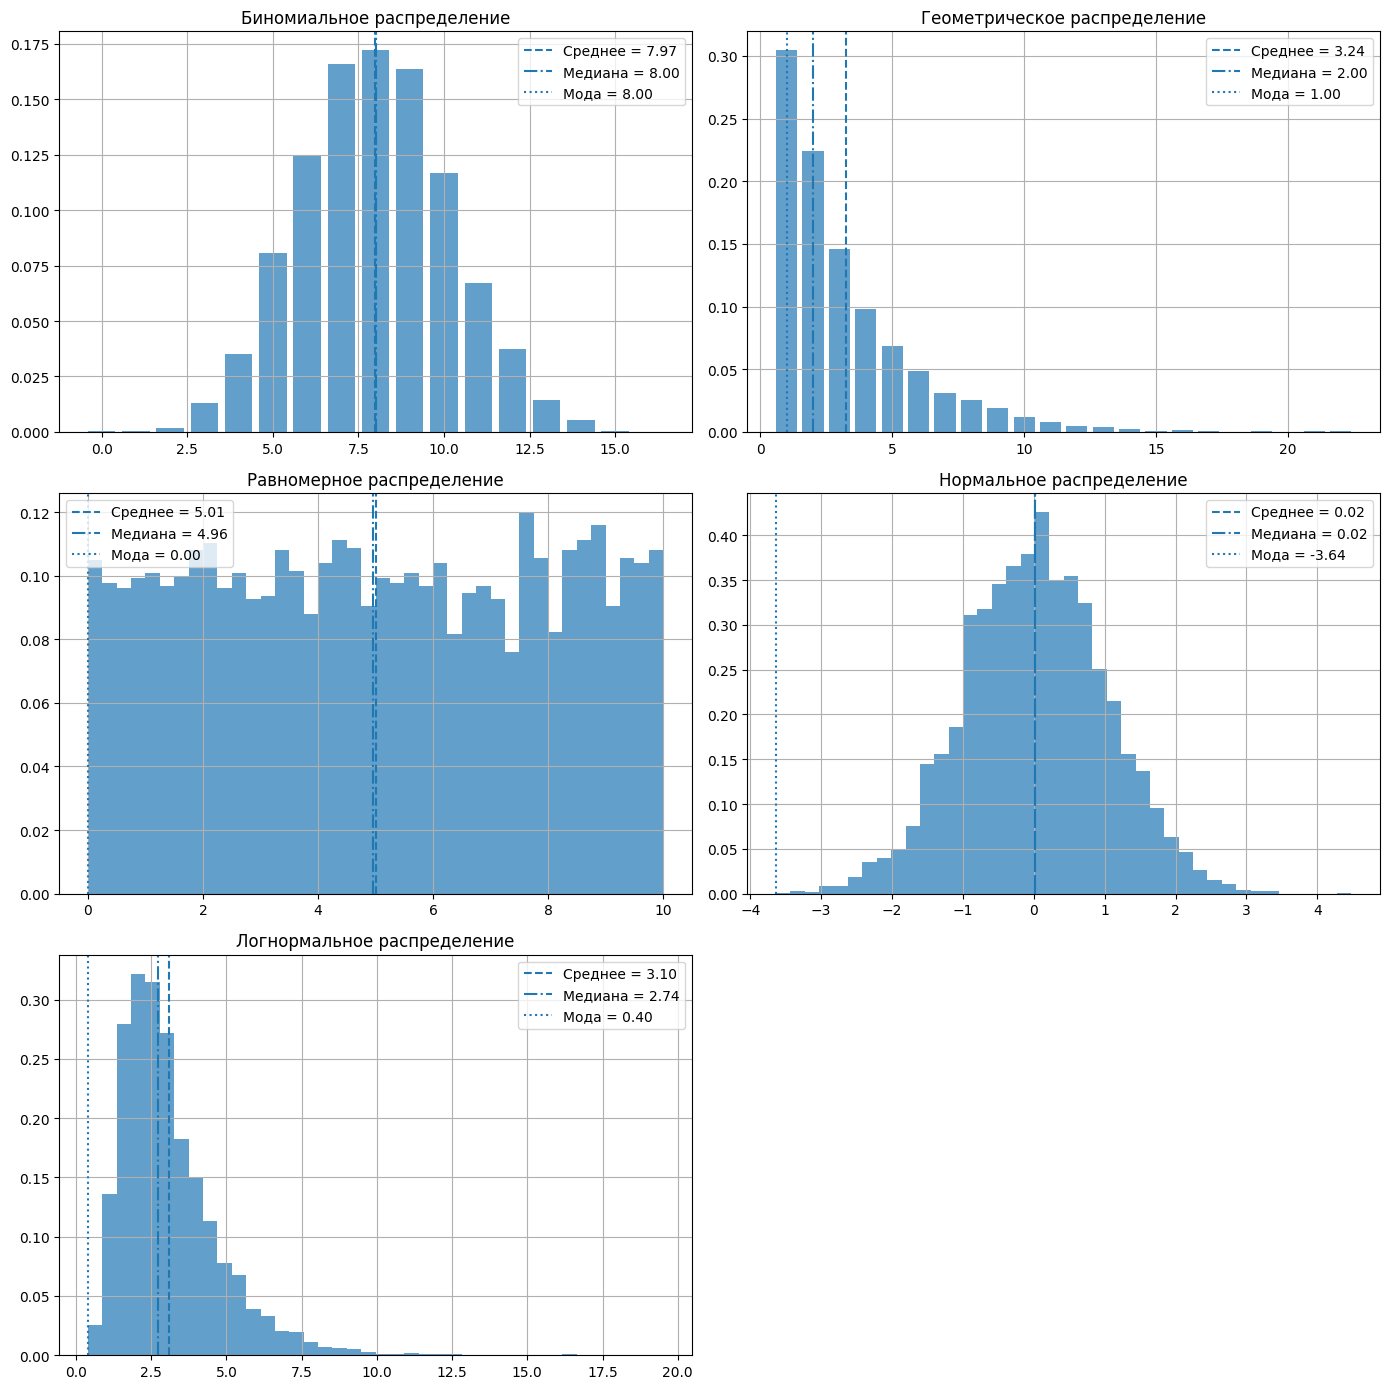

In [ ]:
np.random.seed(42)

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.ravel()

distributions = [
    {
        "name": "Биномиальное распределение",
        "sample": stats.binom.rvs(n=20, p=0.4, size=5000),
        "is_discrete": True,
        "real_example": "число успешных исходов в серии из 20 испытаний"
    },
    {
        "name": "Геометрическое распределение",
        "sample": stats.geom.rvs(p=0.3, size=5000),
        "is_discrete": True,
        "real_example": "число попыток до первого успеха"
    },
    {
        "name": "Равномерное распределение",
        "sample": stats.uniform.rvs(loc=0, scale=10, size=5000),
        "is_discrete": False,
        "real_example": "случайное число на отрезке [0, 10]"
    },
    {
        "name": "Нормальное распределение",
        "sample": stats.norm.rvs(loc=0, scale=1, size=5000),
        "is_discrete": False,
        "real_example": "ошибки измерений, рост людей"
    },
    {
        "name": "Логнормальное распределение",
        "sample": stats.lognorm.rvs(s=0.5, scale=np.exp(1), size=5000),
        "is_discrete": False,
        "real_example": "доходы, цены, времена выполнения"
    }
]

for i, dist in enumerate(distributions):
    sample = dist["sample"]
    ax = axes[i]

    mean_ = np.mean(sample)
    median_ = np.median(sample)
    std_ = np.std(sample, ddof=1)
    mode_ = stats.mode(sample, keepdims=False).mode

    if dist["is_discrete"]:
        values, counts = np.unique(sample, return_counts=True)
        probs = counts / counts.sum()
        ax.bar(values, probs, alpha=0.7)
    else:
        ax.hist(sample, bins=40, density=True, alpha=0.7)

    ax.axvline(mean_, linestyle='--', label=f'Среднее = {mean_:.2f}')
    ax.axvline(median_, linestyle='-.', label=f'Медиана = {median_:.2f}')
    ax.axvline(mode_, linestyle=':', label=f'Мода = {mode_:.2f}')

    ax.set_title(dist["name"])
    ax.legend()
    ax.grid(True)

    print(f"{dist['name']}:")
    print(f"  Реальный пример: {dist['real_example']}")
    print(f"  Среднее: {mean_:.4f}")
    print(f"  Медиана: {median_:.4f}")
    print(f"  Мода: {mode_:.4f}")
    print(f"  Стандартное отклонение: {std_:.4f}")
    print()

axes[-1].axis('off')

plt.tight_layout()
plt.show()

Подумайте, в каких случаях медиана предпочтительнее среднего при расчете "средней температуры по больнице". Какие модификации можно было бы произвести для формулы среднего или для выборки, чтобы среднее значение стало более репрезентативно в подобных случаях? Напишите ответ.

Медиана предпочтительнее среднего в тех случаях, когда в выборке есть выбросы или сильная асимметрия распределения.
Например, если у большинства людей температура около нормальной, а у нескольких очень высокая, среднее может заметно сместиться вверх и перестать быть типичным значением.
Медиана в таких случаях устойчивее к выбросам и лучше отражает "центр" данных.

Чтобы среднее стало более репрезентативным, можно:
1. удалить или ограничить выбросы;
2. использовать усечённое среднее, отбросив крайние значения;
3. применять взвешенное среднее;
4. предварительно разбивать выборку на однородные группы и считать среднее отдельно по группам.

##2 (2 балла)

1000 человек бросают монетку. Каждый бросил 10 раз подряд.

 1. Какова вероятность того, что хотя бы у одного человека монетка выпала 10 раз подряд той же самой стороной (орлом или решкой)?
 2. Какова вероятность того, что хотя бы у одного человека монетка выпала 8 раз подряд той же самой стороной (орлом или решкой)?
 3. Какова вероятность того, что ровно у троих человек из 1000 монетка выпала 10 раз подряд той же самой стороной (орлом или решкой)?

 Рассчитайте вероятности, а также смоделируйте ситуацию и оцените эмпирическое распределение.

In [ ]:
np.random.seed(42)

n_people = 1000
n_throws = 10

p_10_same_one_person = 2 / (2 ** 10)

all_sequences = np.array([list(map(int, format(i, f'0{n_throws}b'))) for i in range(2 ** n_throws)])

def has_run(seq, run_len):
    max_run = 1
    current = 1
    for i in range(1, len(seq)):
        if seq[i] == seq[i - 1]:
            current += 1
            max_run = max(max_run, current)
        else:
            current = 1
    return max_run >= run_len

count_8_same = sum(has_run(seq, 8) for seq in all_sequences)
p_8_same_one_person = count_8_same / (2 ** n_throws)

print("Точные вероятности для одного человека:")
print(f"P(10 одинаковых подряд) = {p_10_same_one_person:.8f}")
print(f"P(хотя бы 8 одинаковых подряд) = {p_8_same_one_person:.8f}")

p_at_least_one_10 = 1 - (1 - p_10_same_one_person) ** n_people

p_at_least_one_8 = 1 - (1 - p_8_same_one_person) ** n_people

p_exactly_3_10 = math.comb(n_people, 3) * (p_10_same_one_person ** 3) * ((1 - p_10_same_one_person) ** (n_people - 3))

print("\nИтоговые вероятности:")
print(f"1) P(хотя бы у одного из 1000 есть 10 одинаковых подряд) = {p_at_least_one_10:.8f}")
print(f"2) P(хотя бы у одного из 1000 есть хотя бы 8 одинаковых подряд) = {p_at_least_one_8:.8f}")
print(f"3) P(ровно у 3 из 1000 есть 10 одинаковых подряд) = {p_exactly_3_10:.8f}")

Точные вероятности для одного человека:
P(10 одинаковых подряд) = 0.00195312
P(хотя бы 8 одинаковых подряд) = 0.01562500

Итоговые вероятности:
1) P(хотя бы у одного из 1000 есть 10 одинаковых подряд) = 0.85844045
2) P(хотя бы у одного из 1000 есть хотя бы 8 одинаковых подряд) = 0.99999986
3) P(ровно у 3 из 1000 есть 10 одинаковых подряд) = 0.17628739


Эмпирические оценки:
1) P(хотя бы у одного есть 10 подряд) ≈ 0.85000000
2) P(хотя бы у одного есть хотя бы 8 подряд) ≈ 1.00000000
3) P(ровно у 3 человек есть 10 подряд) ≈ 0.16400000


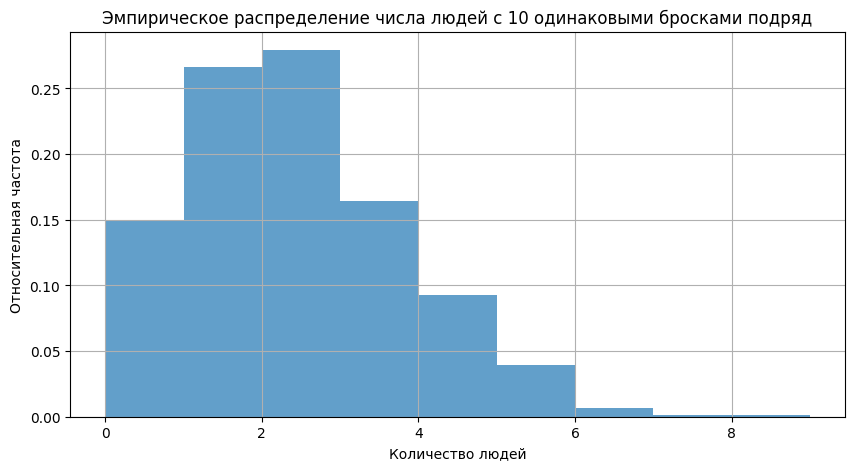

In [ ]:
np.random.seed(42)

n_experiments = 1000
n_people = 1000
n_throws = 10

def max_run_length(seq):
    max_run = 1
    current = 1
    for i in range(1, len(seq)):
        if seq[i] == seq[i - 1]:
            current += 1
            max_run = max(max_run, current)
        else:
            current = 1
    return max_run

count_at_least_one_10 = 0
count_at_least_one_8 = 0
count_exactly_3_10 = 0

num_people_with_10_list = []

for _ in range(n_experiments):
    tosses = np.random.randint(0, 2, size=(n_people, n_throws))
    run_lengths = np.array([max_run_length(seq) for seq in tosses])

    people_with_10 = np.sum(run_lengths >= 10)
    people_with_8 = np.sum(run_lengths >= 8)

    num_people_with_10_list.append(people_with_10)

    if people_with_10 >= 1:
        count_at_least_one_10 += 1
    if people_with_8 >= 1:
        count_at_least_one_8 += 1
    if people_with_10 == 3:
        count_exactly_3_10 += 1

emp_p1 = count_at_least_one_10 / n_experiments
emp_p2 = count_at_least_one_8 / n_experiments
emp_p3 = count_exactly_3_10 / n_experiments

print("Эмпирические оценки:")
print(f"1) P(хотя бы у одного есть 10 подряд) ≈ {emp_p1:.8f}")
print(f"2) P(хотя бы у одного есть хотя бы 8 подряд) ≈ {emp_p2:.8f}")
print(f"3) P(ровно у 3 человек есть 10 подряд) ≈ {emp_p3:.8f}")

plt.figure(figsize=(10, 5))
plt.hist(num_people_with_10_list, bins=range(min(num_people_with_10_list), max(num_people_with_10_list) + 2), density=True, alpha=0.7)
plt.title("Эмпирическое распределение числа людей с 10 одинаковыми бросками подряд")
plt.xlabel("Количество людей")
plt.ylabel("Относительная частота")
plt.grid(True)
plt.show()

##3

В магазин поступила новая продукция с трех предприятий. Процентный состав этой продукции следующий: 20% - продукция первого предприятия, 30% - продукция второго предприятия, 50% - продукция третьего предприятия; далее, 10% продукции первого предприятия высшего сорта, на втором предприятии - 5% и на третьем - 20% продукции высшего сорта. Найти вероятность того, что случайно купленная новая продукция окажется высшего сорта. Если известно, что купленная продукция высшего сорта, какова вероятность, что она была куплена на втором предприятии?

Решите задачу в общем случае для N предприятий, где доля продукции каждого составляет $a_i$, а доля продукции высшего сорта на каждом составляет $b_i$. Напишите функцию, принимающую на вход два списка: a и b, а также n - номер предприятия, для которого необходимо узнать вероятность, что продукция высшего сорта была куплена именно на нём (нумерация с единицы). Функция должна возвращать две вероятности.

In [ ]:
def probabilities_for_factories(a, b, n):
    total_high = sum(ai * bi for ai, bi in zip(a, b))
    conditional = a[n - 1] * b[n - 1] / total_high

    return total_high, conditional


a = [0.2, 0.3, 0.5]
b = [0.1, 0.05, 0.2]

p_high, p_second_given_high = probabilities_for_factories(a, b, 2)

print(f"P(продукция высшего сорта) = {p_high:.4f}")
print(f"P(куплена на 2-м предприятии | высший сорт) = {p_second_given_high:.4f}")

P(продукция высшего сорта) = 0.1350
P(куплена на 2-м предприятии | высший сорт) = 0.1111


Пусть:
$$
A_i
$$
— событие, что товар произведён на предприятии $i$,

$$
P(A_i)=a_i,
$$

а
$$
P(H|A_i)=b_i
$$
— вероятность того, что товар высшего сорта, если он произведён на предприятии $i$.

Тогда вероятность купить товар высшего сорта равна

$$
P(H)=\sum_{i=1}^{N} a_i b_i.
$$

По формуле Байеса вероятность того, что товар высшего сорта был куплен на предприятии $n$, равна

$$
P(A_n|H)=\frac{P(A_n)\,P(H|A_n)}{P(H)}=
\frac{a_n b_n}{\sum_{i=1}^{N} a_i b_i}.
$$

# Методы оптимизации (3 балла)

Дана функция $f(x) = (a\sin(x) + b\ln(x))^2 + cx^2$ и файл, содержащий пары (x, f(x)). Необходимо с точностью до трёх знаков после запятой подобрать коэффициенты a, b, c исходной функции. Для решения задачи предлагается использовать градиентный спуск и функцию потерь MSE.

P.S. на предоставленном наборе данных возможно получить MSE < 0.00001, ориентируйтесь на эту цифру.

In [ ]:
!gdown 1P5REbDVMtoHk_EPOaXzFWym2sMKhhbg3

Downloading...
From: https://drive.google.com/uc?id=1P5REbDVMtoHk_EPOaXzFWym2sMKhhbg3
To: /content/data.txt
100% 27.0k/27.0k [00:00<00:00, 77.6MB/s]


In [ ]:
with open('data.txt', 'r') as file:
    x_data = []
    y_data = []
    for para in eval(file.read()):
        x_data.append(para[0])
        y_data.append(para[1])
x_data = np.array(x_data)
y_data = np.array(y_data)

a = 3.141620
b = 2.718370
c = 3.999969
MSE = 0.0000000000

Округление до 3 знаков:
a = 3.142
b = 2.718
c = 4.000


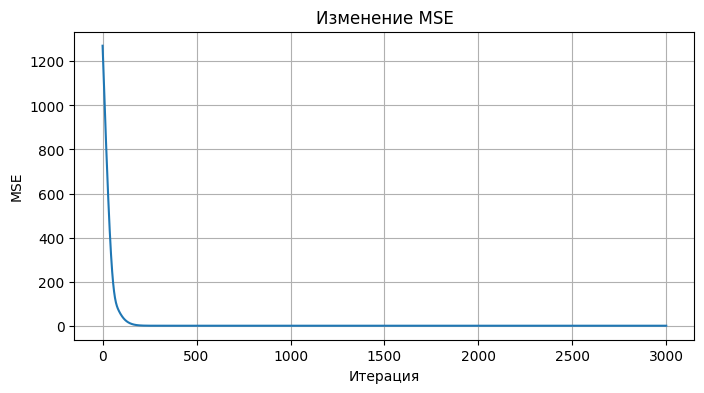

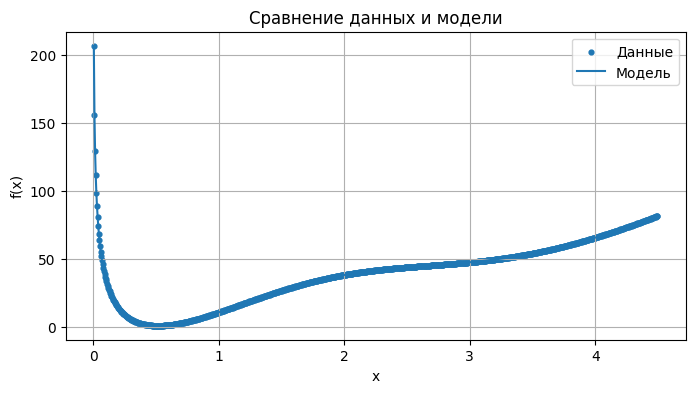

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# данные уже считаны в x_data, y_data
x = torch.tensor(x_data, dtype=torch.float32)
y = torch.tensor(y_data, dtype=torch.float32)

# параметры модели
a = torch.nn.Parameter(torch.tensor(1.0))
b = torch.nn.Parameter(torch.tensor(1.0))
c = torch.nn.Parameter(torch.tensor(1.0))

def model(x):
    return (a * torch.sin(x) + b * torch.log(x))**2 + c * x**2

optimizer = torch.optim.Adam([a, b, c], lr=0.03)

loss_history = []

for _ in range(3000):
    optimizer.zero_grad()
    y_pred = model(x)
    loss = torch.mean((y_pred - y) ** 2)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

print(f"a = {a.item():.6f}")
print(f"b = {b.item():.6f}")
print(f"c = {c.item():.6f}")
print(f"MSE = {loss.item():.10f}")

print("\nОкругление до 3 знаков:")
print(f"a = {a.item():.3f}")
print(f"b = {b.item():.3f}")
print(f"c = {c.item():.3f}")

# график ошибки
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Изменение MSE")
plt.xlabel("Итерация")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

# сравнение данных и модели
with torch.no_grad():
    y_pred = model(x).numpy()

plt.figure(figsize=(8, 4))
plt.scatter(x_data, y_data, s=12, label="Данные")
plt.plot(x_data, y_pred, label="Модель")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Сравнение данных и модели")
plt.legend()
plt.grid(True)
plt.show()